## Hybrid transfer-learning evaluation results

Loads each fold model from the hybrid transfer-learning final evaluation, runs inference on the held-out test fold, and aggregates the results into per-fold and class-wise metrics. Saves a per-fold metrics CSV, a class-wise metrics JSON, an aggregated classification report, an aggregated confusion matrix figure, and a top-misclassifications plot. 

The final cell runs a paired t-test comparing per-fold test accuracies between the authentic-only and hybrid models.

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy import stats
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score, accuracy_score

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
EVAL_DATA_ROOT = "/content/drive/MyDrive/authentic_split_cv_eval"
MODEL_DIR = "/content/drive/MyDrive/authentic_training_cv_eval/model3/winner_lr5e-05_lay60_drop0p3_0p6"
OUTPUT_DIR = "/content/drive/MyDrive/authentic_training_cv_eval/model3_analysis"

os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = ["t72", "t80", "t90"]
NUM_FOLDS = 5
IMG_SIZE = (682, 1024)
BATCH_SIZE = 4

print(f"Eval data: {EVAL_DATA_ROOT}")
print(f"Model folder: {MODEL_DIR}")
print(f"Output folder: {OUTPUT_DIR}")

Eval data: /content/drive/MyDrive/authentic_split_cv_eval
Model folder: /content/drive/MyDrive/authentic_training_cv_eval/model3/winner_lr5e-05_lay60_drop0p3_0p6
Output folder: /content/drive/MyDrive/authentic_training_cv_eval/model3_analysis


In [3]:
# Load each fold, predict, and compute fold metrics
per_fold_predictions = {}
per_fold_metrics = {}

for fold_idx in range(NUM_FOLDS):
    print(f"\n--- Fold {fold_idx} ---")
    model_path = os.path.join(MODEL_DIR, f"model_fold{fold_idx}.keras")
    test_dir = os.path.join(EVAL_DATA_ROOT, f"fold_{fold_idx}", "test")

    if not os.path.exists(model_path):
        print(f"Missing model: {model_path}")
        continue
    if not os.path.exists(test_dir):
        print(f"Missing test data: {test_dir}")
        continue

    model = keras.models.load_model(model_path)

    test_ds = keras.utils.image_dataset_from_directory(
        test_dir,
        labels="inferred",
        label_mode="int",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        crop_to_aspect_ratio=True,
    )

    y_true = []
    y_pred = []
    for batch_imgs, batch_labels in test_ds:
        preds = model.predict(batch_imgs, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(batch_labels.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    per_fold_predictions[fold_idx] = (y_true, y_pred)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", labels=[0, 1, 2], zero_division=0)
    macro_prec = precision_score(y_true, y_pred, average="macro", labels=[0, 1, 2], zero_division=0)
    macro_rec = recall_score(y_true, y_pred, average="macro", labels=[0, 1, 2], zero_division=0)

    per_fold_metrics[fold_idx] = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "macro_precision": macro_prec,
        "macro_recall": macro_rec,
    }

    print(
        f"Fold {fold_idx} metrics: accuracy={acc:.4f}, "
        f"macro_f1={macro_f1:.4f}, precision={macro_prec:.4f}, recall={macro_rec:.4f}"
    )

    del model
    keras.backend.clear_session()

print("All folds processed.")


--- Fold 0 ---
Found 171 files belonging to 3 classes.
Fold 0 metrics: accuracy=0.8363, macro_f1=0.8046, precision=0.8287, recall=0.7923

--- Fold 1 ---
Found 171 files belonging to 3 classes.
Fold 1 metrics: accuracy=0.8070, macro_f1=0.7893, precision=0.8144, recall=0.7769

--- Fold 2 ---
Found 172 files belonging to 3 classes.
Fold 2 metrics: accuracy=0.8721, macro_f1=0.8522, precision=0.8512, recall=0.8568

--- Fold 3 ---
Found 171 files belonging to 3 classes.
Fold 3 metrics: accuracy=0.7310, macro_f1=0.7200, precision=0.7338, recall=0.7294

--- Fold 4 ---
Found 171 files belonging to 3 classes.
Fold 4 metrics: accuracy=0.8655, macro_f1=0.8486, precision=0.8508, recall=0.8515
All folds processed.


In [4]:
# Aggregate per-fold metrics and save summary
metrics_df = pd.DataFrame(per_fold_metrics).T
metrics_df.index.name = "fold"

print("\nPer-fold metrics:")
print(metrics_df.to_string())

print("\nAggregated metrics:")
print(f"Accuracy       {metrics_df['accuracy'].mean():.4f} ± {metrics_df['accuracy'].std():.4f}")
print(f"Macro F1       {metrics_df['macro_f1'].mean():.4f} ± {metrics_df['macro_f1'].std():.4f}")
print(f"Macro Precision{metrics_df['macro_precision'].mean():.4f} ± {metrics_df['macro_precision'].std():.4f}")
print(f"Macro Recall   {metrics_df['macro_recall'].mean():.4f} ± {metrics_df['macro_recall'].std():.4f}")

metrics_df.to_csv(os.path.join(OUTPUT_DIR, "per_fold_metrics.csv"))
print(f"Saved per-fold metrics to: {OUTPUT_DIR}/per_fold_metrics.csv")


Per-fold metrics:
      accuracy  macro_f1  macro_precision  macro_recall
fold                                                   
0     0.836257  0.804595         0.828749      0.792294
1     0.807018  0.789310         0.814447      0.776941
2     0.872093  0.852178         0.851225      0.856754
3     0.730994  0.719984         0.733782      0.729419
4     0.865497  0.848646         0.850813      0.851496

Aggregated metrics:
Accuracy       0.8224 ± 0.0573
Macro F1       0.8029 ± 0.0538
Macro Precision0.8158 ± 0.0484
Macro Recall   0.8014 ± 0.0535
Saved per-fold metrics to: /content/drive/MyDrive/authentic_training_cv_eval/model3_analysis/per_fold_metrics.csv


In [5]:
# Compute class-wise metrics per fold and aggregate them
class_metrics_per_fold = {}

for fold_idx, (y_true, y_pred) in per_fold_predictions.items():
    f1_per_class = f1_score(y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    prec_per_class = precision_score(y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    rec_per_class = recall_score(y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    support_per_class = [int(np.sum(y_true == i)) for i in range(3)]

    class_metrics_per_fold[fold_idx] = {
        cls: {
            "precision": float(prec_per_class[class_idx]),
            "recall": float(rec_per_class[class_idx]),
            "f1": float(f1_per_class[class_idx]),
            "support": support_per_class[class_idx],
        }
        for class_idx, cls in enumerate(CLASS_NAMES)
    }

print("\nClass-wise aggregated metrics:")
class_aggregate = {}
for cls in CLASS_NAMES:
    precisions = [class_metrics_per_fold[f][cls]["precision"] for f in class_metrics_per_fold]
    recalls = [class_metrics_per_fold[f][cls]["recall"] for f in class_metrics_per_fold]
    f1s = [class_metrics_per_fold[f][cls]["f1"] for f in class_metrics_per_fold]
    supports = [class_metrics_per_fold[f][cls]["support"] for f in class_metrics_per_fold]

    class_aggregate[cls] = {
        "precision_mean": np.mean(precisions),
        "precision_std": np.std(precisions, ddof=1),
        "recall_mean": np.mean(recalls),
        "recall_std": np.std(recalls, ddof=1),
        "f1_mean": np.mean(f1s),
        "f1_std": np.std(f1s, ddof=1),
        "support_total": sum(supports),
    }

    print(
        f"{cls}: precision={class_aggregate[cls]['precision_mean']:.4f} ± {class_aggregate[cls]['precision_std']:.4f}, "
        f"recall={class_aggregate[cls]['recall_mean']:.4f} ± {class_aggregate[cls]['recall_std']:.4f}, "
        f"f1={class_aggregate[cls]['f1_mean']:.4f} ± {class_aggregate[cls]['f1_std']:.4f}, "
        f"support={class_aggregate[cls]['support_total']}"
    )

with open(os.path.join(OUTPUT_DIR, "classwise_metrics.json"), "w") as f:
    json.dump({"per_fold": class_metrics_per_fold, "aggregated": class_aggregate}, f, indent=2)
print(f"Saved class-wise metrics to: {OUTPUT_DIR}/classwise_metrics.json")


Class-wise aggregated metrics:
t72: precision=0.8793 ± 0.0429, recall=0.8589 ± 0.0872, f1=0.8671 ± 0.0564, support=447
t80: precision=0.7577 ± 0.1178, recall=0.8344 ± 0.0493, f1=0.7893 ± 0.0682, support=236
t90: precision=0.8104 ± 0.0573, recall=0.7109 ± 0.0975, f1=0.7523 ± 0.0430, support=173
Saved class-wise metrics to: /content/drive/MyDrive/authentic_training_cv_eval/model3_analysis/classwise_metrics.json


In [6]:
# Create aggregate classification report across folds
all_y_true = []
all_y_pred = []
for fold_idx in sorted(per_fold_predictions):
    y_true, y_pred = per_fold_predictions[fold_idx]
    all_y_true.extend(y_true)
    all_y_pred.extend(y_pred)

print("\nAggregated classification report:")
report = classification_report(all_y_true, all_y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0)
print(report)

with open(os.path.join(OUTPUT_DIR, "classification_report.txt"), "w") as f:
    f.write(report)
print(f"Saved classification report to: {OUTPUT_DIR}/classification_report.txt")


Aggregated classification report:
              precision    recall  f1-score   support

         t72     0.8787    0.8591    0.8688       447
         t80     0.7406    0.8347    0.7849       236
         t90     0.8039    0.7110    0.7546       173

    accuracy                         0.8224       856
   macro avg     0.8077    0.8016    0.8027       856
weighted avg     0.8255    0.8224    0.8226       856

Saved classification report to: /content/drive/MyDrive/authentic_training_cv_eval/model3_analysis/classification_report.txt


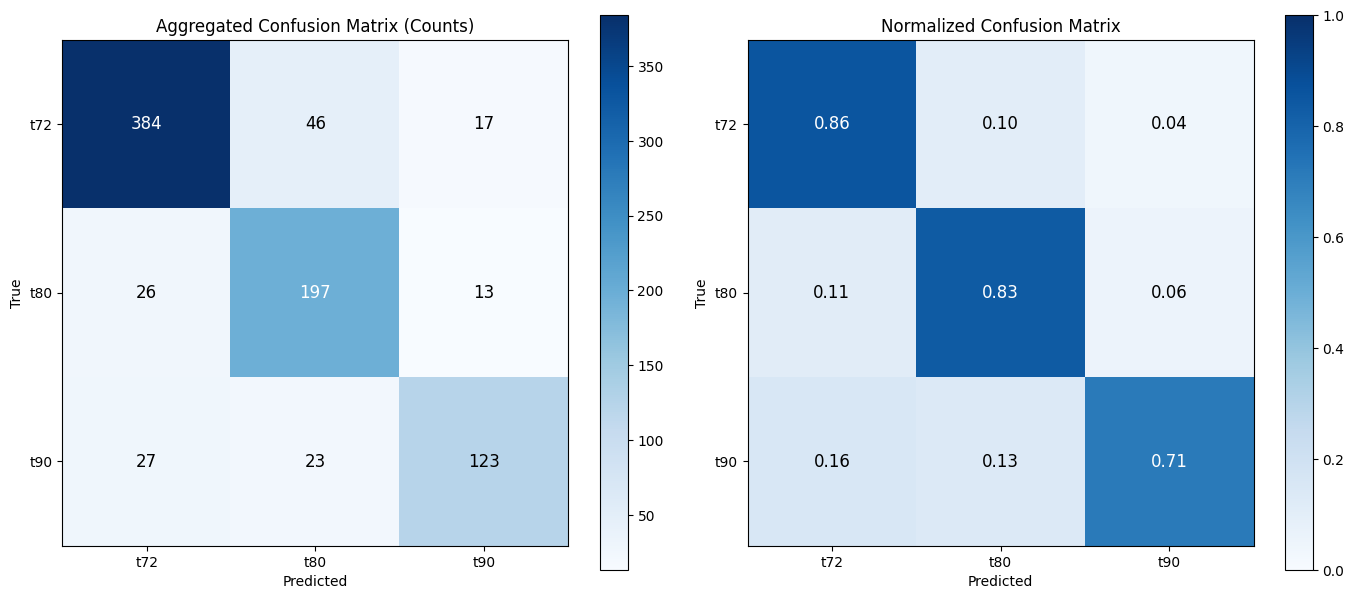

Saved confusion matrix figure to: /content/drive/MyDrive/authentic_training_cv_eval/model3_analysis/aggregated_confusion_matrix.png
Saved confusion matrices summary.


In [7]:
# Create and save aggregated confusion matrices and plots
cm_total = np.zeros((3, 3), dtype=int)
for fold_idx in per_fold_predictions:
    y_true, y_pred = per_fold_predictions[fold_idx]
    cm_total += confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

cm_normalized = cm_total.astype(float) / cm_total.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im1 = axes[0].imshow(cm_total, cmap="Blues")
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_yticks(range(3)); axes[0].set_yticklabels(CLASS_NAMES)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_title("Aggregated Confusion Matrix (Counts)")
for i in range(3):
    for j in range(3):
        text_color = "white" if cm_total[i, j] > cm_total.max() / 2 else "black"
        axes[0].text(j, i, str(cm_total[i, j]), ha="center", va="center", color=text_color, fontsize=12)
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(CLASS_NAMES)
axes[1].set_yticks(range(3)); axes[1].set_yticklabels(CLASS_NAMES)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].set_title("Normalized Confusion Matrix")
for i in range(3):
    for j in range(3):
        text_color = "white" if cm_normalized[i, j] > 0.5 else "black"
        axes[1].text(j, i, f"{cm_normalized[i, j]:.2f}", ha="center", va="center", color=text_color, fontsize=12)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
conf_mat_path = os.path.join(OUTPUT_DIR, "aggregated_confusion_matrix.png")
plt.savefig(conf_mat_path, dpi=150)
plt.show()
print(f"Saved confusion matrix figure to: {conf_mat_path}")

with open(os.path.join(OUTPUT_DIR, "confusion_matrices.json"), "w") as f:
    json.dump({
        "counts": cm_total.tolist(),
        "normalized": cm_normalized.tolist(),
        "class_names": CLASS_NAMES,
    }, f, indent=2)
print("Saved confusion matrices summary.")


Top misclassifications:
  T72 → T80: 46
  T90 → T72: 27
  T80 → T72: 26
  T90 → T80: 23
  T72 → T90: 17
  T80 → T90: 13


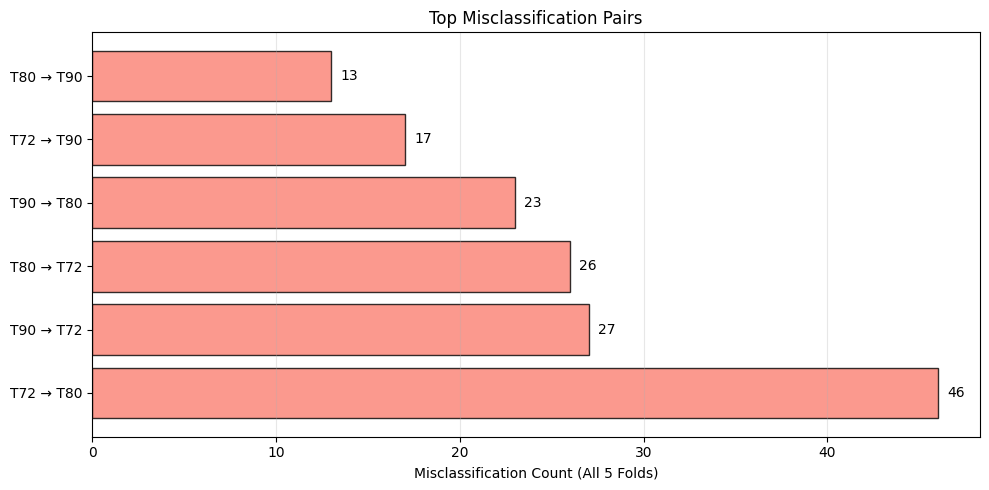

Saved top misclassification plot to: /content/drive/MyDrive/authentic_training_cv_eval/model3_analysis/top_misclassifications.png


In [8]:
# Top misclassification pairs across folds
errors = {
    f"{CLASS_NAMES[i].upper()} → {CLASS_NAMES[j].upper()}": int(cm_total[i, j])
    for i in range(3)
    for j in range(3)
    if i != j
}

sorted_errors = dict(sorted(errors.items(), key=lambda item: -item[1]))
print("\nTop misclassifications:")
for key, val in sorted_errors.items():
    print(f"  {key}: {val}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(sorted_errors.keys()), list(sorted_errors.values()), color="salmon", edgecolor="black", alpha=0.8)
ax.set_xlabel("Misclassification Count (All 5 Folds)")
ax.set_title("Top Misclassification Pairs")
ax.grid(axis="x", alpha=0.3)
for i, (key, val) in enumerate(sorted_errors.items()):
    ax.text(val + 0.5, i, str(val), va="center", fontsize=10)

plt.tight_layout()
misclass_path = os.path.join(OUTPUT_DIR, "top_misclassifications.png")
plt.savefig(misclass_path, dpi=150)
plt.show()
print(f"Saved top misclassification plot to: {misclass_path}")

In [2]:
"""
Paired t-test: Authentic-only vs Hybrid model
============================================
Compares per-fold test accuracies from the evaluation split.
"""


# Paths to the saved results
M1_RESULTS = "/content/drive/MyDrive/authentic_training_cv_eval/model1/winner_config6_lr3e-05_lay60_drop0p3_0p6/results.json"
M3_RESULTS = "/content/drive/MyDrive/authentic_training_cv_eval/model3/winner_lr5e-05_lay60_drop0p3_0p6/results.json"

NUM_FOLDS = 5

# Load results
with open(M1_RESULTS, "r") as f:
    m1_results = json.load(f)
with open(M3_RESULTS, "r") as f:
    m3_results = json.load(f)

m1 = np.array([m1_results[f"fold_{i}"]["test_accuracy"] for i in range(NUM_FOLDS)])
m3 = np.array([m3_results[f"fold_{i}"]["test_accuracy"] for i in range(NUM_FOLDS)])

# Descriptive statistics
print("Descriptive statistics")
print(f"Authentic-only per-fold: {[f'{a:.4f}' for a in m1]}")
print(f"  Mean: {m1.mean():.4f}  SD: {m1.std(ddof=1):.4f}")
print(f"Hybrid per-fold:         {[f'{a:.4f}' for a in m3]}")
print(f"  Mean: {m3.mean():.4f}  SD: {m3.std(ddof=1):.4f}")

# Per-fold differences
diff = m1 - m3
print("\nPer-fold differences (authentic-only minus hybrid):")
for i, d in enumerate(diff):
    print(f"  Fold {i}: {d:+.4f}")
print(f"  Mean difference:   {diff.mean():+.4f}")
print(f"  SD of differences: {diff.std(ddof=1):.4f}")

# Paired t-test
t_stat, p_value = stats.ttest_rel(m1, m3)

# Cohen's d for paired samples and a 95% CI on the mean difference.
cohens_d = diff.mean() / diff.std(ddof=1)
sem = diff.std(ddof=1) / np.sqrt(NUM_FOLDS)
ci_margin = stats.t.ppf(0.975, NUM_FOLDS - 1) * sem
ci_low = diff.mean() - ci_margin
ci_high = diff.mean() + ci_margin

print("\nPaired t-test")
print(f"  t-statistic:                {t_stat:.4f}")
print(f"  p-value:                    {p_value:.4f}")
print(f"  Degrees of freedom:         {NUM_FOLDS - 1}")
print(f"  Cohen's d:                  {cohens_d:.4f}")
print(f"  95% CI for mean difference: [{ci_low:+.4f}, {ci_high:+.4f}]")


print("\nInterpretation")
if p_value < 0.05:
    print(f"  p = {p_value:.4f} < 0.05 — statistically significant difference between the two models.")
else:
    print(f"  p = {p_value:.4f} >= 0.05 — no statistically significant difference.")


Descriptive statistics
Authentic-only per-fold: ['0.8830', '0.8830', '0.8663', '0.8421', '0.8772']
  Mean: 0.8703  SD: 0.0172
Hybrid per-fold:         ['0.8363', '0.8070', '0.8721', '0.7310', '0.8655']
  Mean: 0.8224  SD: 0.0573

Per-fold differences (authentic-only minus hybrid):
  Fold 0: +0.0468
  Fold 1: +0.0760
  Fold 2: -0.0058
  Fold 3: +0.1111
  Fold 4: +0.0117
  Mean difference:   +0.0480
  SD of differences: 0.0474

Paired t-test
  t-statistic:                2.2629
  p-value:                    0.0864
  Degrees of freedom:         4
  Cohen's d:                  1.0120
  95% CI for mean difference: [-0.0109, +0.1068]

Interpretation
  p = 0.0864 >= 0.05 — no statistically significant difference.
